In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from optbinning import OptimalBinning

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

fraud_df = pd.read_csv('../data/creditcard.csv')

fraud_df['Amount_log'] = np.log1p(fraud_df['Amount'])
fraud_df['Hour'] = (fraud_df['Time']/3600 % 24).astype(int)
fraud_df = fraud_df.sort_values('Time').reset_index(drop=True)


fraud_df['rolling_avg_amount'] = fraud_df['Amount'].rolling(window= 100, min_periods=1).mean()
fraud_df['rolling_std_amount'] = fraud_df['Amount'].rolling(window=100, min_periods=1).std()
fraud_df['rolling_fraud_density'] = fraud_df['Class'].rolling(window=100, min_periods=1).mean()*100
fraud_df['rolling_txn_count']=fraud_df['Amount'].rolling(window=100, min_periods=1).count()
fraud_df['rolling_std_amount'] = fraud_df['rolling_std_amount'].fillna(0)  



print(f"Data loaded: {fraud_df.shape}")
print(f"Columns: {fraud_df.columns.tolist()}")

(CVXPY) May 27 03:18:41 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 27 03:18:41 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


Data loaded: (284807, 37)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_log', 'Hour', 'rolling_avg_amount', 'rolling_std_amount', 'rolling_fraud_density', 'rolling_txn_count']


In [2]:

train_idx    = int(len(fraud_df) * 0.70)
validate_idx = int(len(fraud_df) * 0.85)

import json
import os

os.makedirs('../models', exist_ok=True)

splits = {
    'train_idx':    train_idx,
    'validate_idx': validate_idx,
    'total_rows':   len(fraud_df)
}

with open('../models/splits.json', 'w') as f:
    json.dump(splits, f, indent=4)

print(f"Splits defined and saved ")
print(f"Train:    rows 0 to {train_idx}")
print(f"Validate: rows {train_idx} to {validate_idx}")
print(f"Test:     rows {validate_idx} to {len(fraud_df)}")

Splits defined and saved 
Train:    rows 0 to 199364
Validate: rows 199364 to 242085
Test:     rows 242085 to 284807


In [3]:

features_to_drop = ['Time',    # replaced by Hour
                    'Amount',  # replaced by Amount_log
                    'Class',   # target variable
                    ]

X = fraud_df.drop(columns=features_to_drop)
y = fraud_df['Class']

# split using saved indices
X_train    = X.iloc[:train_idx]
X_validate = X.iloc[train_idx:validate_idx]
X_test     = X.iloc[validate_idx:]

y_train    = y.iloc[:train_idx]
y_validate = y.iloc[train_idx:validate_idx]
y_test     = y.iloc[validate_idx:]

print(f"Full feature set: {X.shape[1]} features")
print(f"Features: {X.columns.tolist()}")
print(f"\nTrain:    {X_train.shape}")
print(f"Validate: {X_validate.shape}")
print(f"Test:     {X_test.shape}")

Full feature set: 34 features
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour', 'rolling_avg_amount', 'rolling_std_amount', 'rolling_fraud_density', 'rolling_txn_count']

Train:    (199364, 34)
Validate: (42721, 34)
Test:     (42722, 34)


In [4]:
# optimal binning on Amount_log — train only
x_amount = X_train['Amount_log'].values
y_train_vals = y_train.values

optb_amount = OptimalBinning(name='Amount_log', dtype='numerical', solver='cp')
optb_amount.fit(x_amount, y_train_vals)

# build full table — keep all rows including per-bin IV
binning_table = optb_amount.binning_table.build()

# remove Special, Missing, Totals — keep only actual bins
binning_table_clean = binning_table[
    ~binning_table['Bin'].isin(['Special', 'Missing', 'Totals'])
].copy()
binning_table_clean = binning_table_clean.apply(
    lambda x: pd.to_numeric(x, errors='ignore')
)

print("Amount_log Binning Table (Train Only — OOT Compliant):")
print(binning_table[['Bin', 'Count', 'Event', 'Event rate', 'WoE', 'IV']])

Amount_log Binning Table (Train Only — OOT Compliant):
                 Bin   Count  Event  Event rate    WoE    IV
0       (-inf, 0.78)   21750    145       0.007 -1.246 0.335
1       [0.78, 2.27)   36369     39       0.001  0.587 0.048
2       [2.27, 2.59)   18204     10       0.001  1.256 0.082
3       [2.59, 2.86)   11365      1       0.000  3.088 0.168
4       [2.86, 3.44)   23546     16       0.001  1.043 0.080
5       [3.44, 4.34)   36553     30       0.001  0.854 0.090
6       [4.34, 4.61)   10228     13       0.001  0.416 0.007
7       [4.61, 5.48)   24287     70       0.003 -0.404 0.024
8        [5.48, inf)   17062     60       0.004 -0.604 0.043
9            Special       0      0       0.000  0.000 0.000
10           Missing       0      0       0.000  0.000 0.000
Totals                199364    384       0.002        0.878


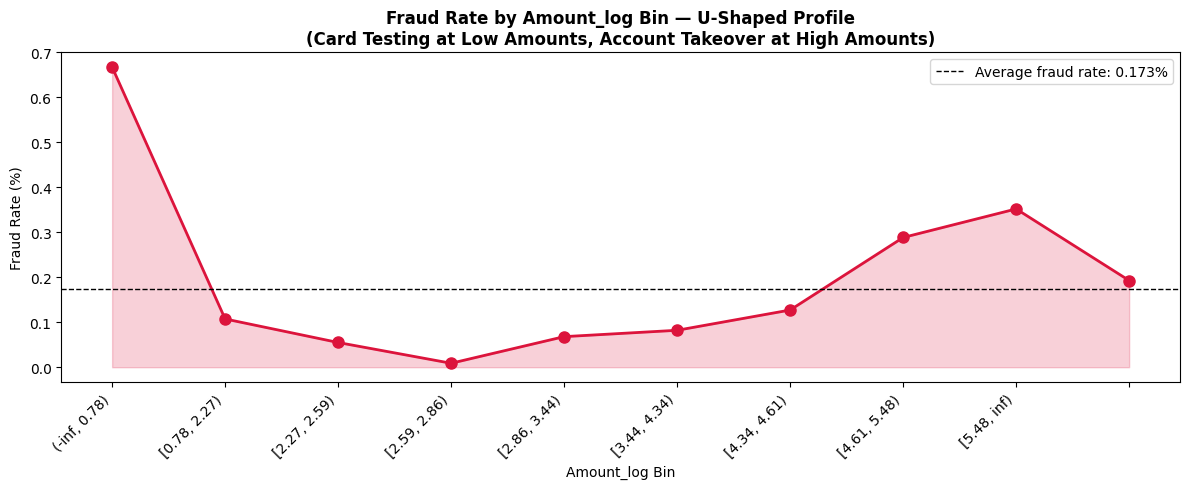

In [ ]:
#  fraud profile — Amount_log bins
plt.figure(figsize=(12, 5))

bins = binning_table_clean['Bin'].astype(str)
fraud_rates = binning_table_clean['Event rate'] * 100

plt.plot(range(len(bins)), fraud_rates, 
         color='crimson', marker='o', linewidth=2, markersize=8)

# fill under the curve to show U-shape clearly
plt.fill_between(range(len(bins)), fraud_rates, 
                 alpha=0.2, color='crimson')

# average line
plt.axhline(y=fraud_df['Class'].mean()*100, color='black',
            linestyle='--', linewidth=1,
            label=f'Average fraud rate: {fraud_df["Class"].mean()*100:.3f}%')

plt.xticks(range(len(bins)), bins, rotation=45, ha='right')
plt.title('Fraud Rate by Amount_log Bin — U-Shaped Profile\n(Card Testing at Low Amounts, Account Takeover at High Amounts)',
          fontweight='bold')
plt.xlabel('Amount_log Bin')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
iv_results ={}
binning_objects={}

for feature in X_train.columns:
    try:
        x_tr =X_train[feature].values
        y_tr = y_train.values

        optb=OptimalBinning(name=feature, dtype='numerical', solver='cp')
        optb.fit(x_tr, y_tr)

        iv =optb.binning_table.build()['IV'].iloc[-1]
        iv_results[feature]=iv

        binning_objects[feature]=optb

        print(f"{feature}: IV = {iv:.4f}")
    except Exception as e:
        print(f"{feature}:Error -{e}")

    # convert to dataframe and sort
iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print("\nFeature IV Rankings (train only — no leakage):")
print(iv_df)



V1: IV = 1.8654
V2: IV = 2.7309
V3: IV = 3.4906
V4: IV = 3.8198
V5: IV = 1.9170
V6: IV = 1.5150
V7: IV = 2.8861
V8: IV = 1.5289
V9: IV = 2.0403
V10: IV = 3.8401
V11: IV = 3.5438
V12: IV = 4.0498
V13: IV = 0.1280
V14: IV = 4.4767
V15: IV = 0.1001
V16: IV = 3.4691
V17: IV = 3.9164
V18: IV = 2.1036
V19: IV = 1.0549
V20: IV = 1.0532
V21: IV = 2.4880
V22: IV = 0.1486
V23: IV = 0.8846
V24: IV = 0.2694
V25: IV = 0.2457
V26: IV = 0.0826
V27: IV = 2.1810
V28: IV = 1.9977
Amount_log: IV = 0.8777
Hour: IV = 0.3632
rolling_avg_amount: IV = 0.0524
rolling_std_amount: IV = 0.1153
rolling_fraud_density: IV = 0.0000
rolling_txn_count: IV = 0.0000

Feature IV Rankings (train only — no leakage):
                         IV
V14                   4.477
V12                   4.050
V17                   3.916
V10                   3.840
V4                    3.820
V11                   3.544
V3                    3.491
V16                   3.469
V7                    2.886
V2                    2.731
V21  

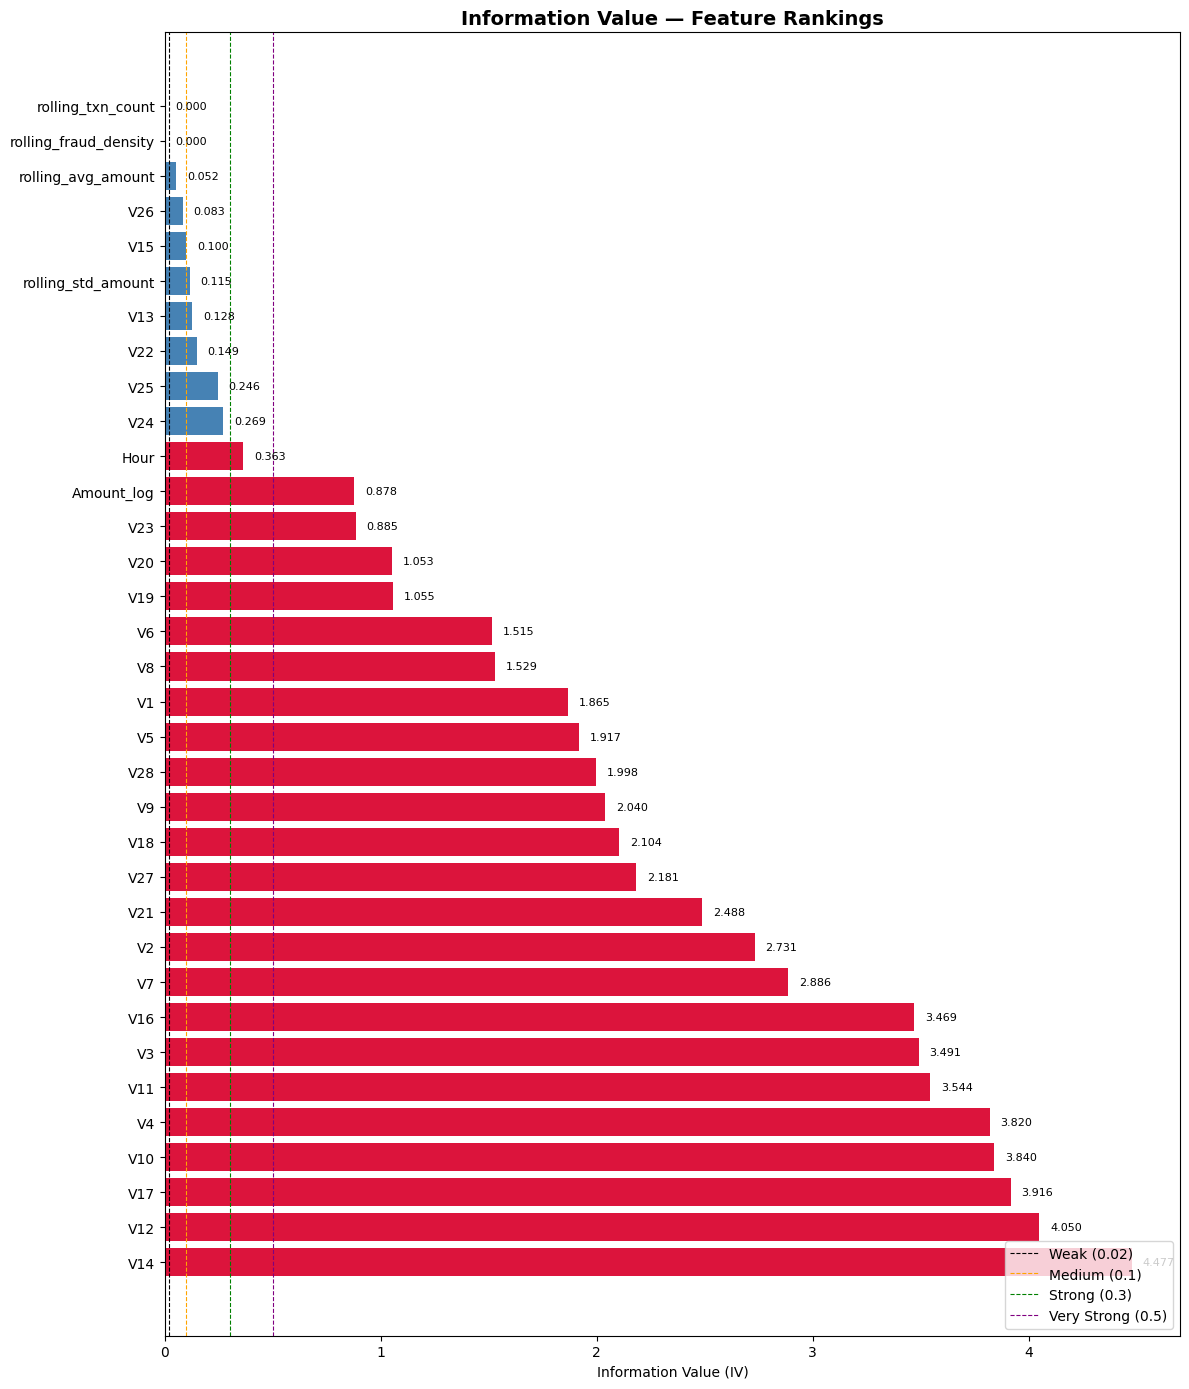

In [6]:
# visualise IV rankings for all features
fig, ax = plt.subplots(figsize=(12, 14))

colors = ['crimson' if iv > 0.3 else 'steelblue' for iv in iv_df['IV']]
ax.barh(iv_df.index, iv_df['IV'], color=colors)

# IV threshold lines
ax.axvline(x=0.02, color='black', linestyle='--', linewidth=0.8, label='Weak (0.02)')
ax.axvline(x=0.1,  color='orange', linestyle='--', linewidth=0.8, label='Medium (0.1)')
ax.axvline(x=0.3,  color='green', linestyle='--', linewidth=0.8, label='Strong (0.3)')
ax.axvline(x=0.5,  color='purple', linestyle='--', linewidth=0.8, label='Very Strong (0.5)')

ax.set_title('Information Value — Feature Rankings', fontweight='bold', fontsize=14)
ax.set_xlabel('Information Value (IV)')
ax.legend(loc='lower right')



for i, (idx, row) in enumerate(iv_df.iterrows()):
    ax.text(row['IV'] + 0.05, i, f'{row["IV"]:.3f}', va='center', fontsize=8)


plt.tight_layout()
plt.show()

In [7]:

features_to_drop_final = ['Time',                  # replaced by Hour
                           'Amount',               # replaced by Amount_log
                           'Class',                # target variable
                           'rolling_txn_count',    # IV=0.000, no predictive power
                           'rolling_fraud_density',# IV=0.000, target leakage
                           'rolling_avg_amount',   # IV=0.052, weak + global not per customer
                           'V26',                  # IV=0.083, weak
                           ]

# final feature set
X_final = fraud_df.drop(columns=features_to_drop_final)
y_final = fraud_df['Class']

# final splits
X_train_final    = X_final.iloc[:train_idx]
X_validate_final = X_final.iloc[train_idx:validate_idx]
X_test_final     = X_final.iloc[validate_idx:]

y_train_final    = y_final.iloc[:train_idx]
y_validate_final = y_final.iloc[train_idx:validate_idx]
y_test_final     = y_final.iloc[validate_idx:]

print(f"Final feature set: {X_final.shape[1]} features")
print(f"Features kept: {X_final.columns.tolist()}")
print(f"\nTrain:    {X_train_final.shape}")
print(f"Validate: {X_validate_final.shape}")
print(f"Test:     {X_test_final.shape}")

# save final feature list
import json
final_features = X_final.columns.tolist()
with open('../models/final_features.json', 'w') as f:
    json.dump(final_features, f, indent=4)

print("\nFinal feature list saved ")

Final feature set: 30 features
Features kept: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V27', 'V28', 'Amount_log', 'Hour', 'rolling_std_amount']

Train:    (199364, 30)
Validate: (42721, 30)
Test:     (42722, 30)

Final feature list saved 


In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# save final splits for modelling notebook
joblib.dump(X_train_final,    '../models/X_train.pkl')
joblib.dump(X_validate_final, '../models/X_validate.pkl')
joblib.dump(X_test_final,     '../models/X_test.pkl')
joblib.dump(y_train_final,    '../models/y_train.pkl')
joblib.dump(y_validate_final, '../models/y_validate.pkl')
joblib.dump(y_test_final,     '../models/y_test.pkl')

print("All splits saved ")
print(f"X_train shape: {X_train_final.shape}")

All splits saved 
X_train shape: (199364, 30)


In [ ]:
# save IV results for use in evaluation notebook
iv_df.to_csv('../models/iv_rankings.csv')
print("IV rankings saved ")



IV rankings saved 
                         IV
V14                   4.477
V12                   4.050
V17                   3.916
V10                   3.840
V4                    3.820
V11                   3.544
V3                    3.491
V16                   3.469
V7                    2.886
V2                    2.731
V21                   2.488
V27                   2.181
V18                   2.104
V9                    2.040
V28                   1.998
V5                    1.917
V1                    1.865
V8                    1.529
V6                    1.515
V19                   1.055
V20                   1.053
V23                   0.885
Amount_log            0.878
Hour                  0.363
V24                   0.269
V25                   0.246
V22                   0.149
V13                   0.128
rolling_std_amount    0.115
V15                   0.100
V26                   0.083
rolling_avg_amount    0.052
rolling_fraud_density 0.000
rolling_txn_count     0.000
